# Feature Engineering for Customer Churn Prediction

## 1. Import Required Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore Data

In [53]:
# Load the dataset
df = pd.read_csv('Customer-Churn-Records.csv')

print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Info:")
print(df.info())

Dataset Shape: (10000, 18)

First Few Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1        

## 3. Exploratory Data Analysis (EDA)

In [54]:
# Create a copy for feature engineering
df_fe = df.copy()

# Check missing values
print("Missing Values:")
print(df_fe.isnull().sum())

# Identify numerical and categorical columns
numerical_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_fe.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Columns ({len(numerical_cols)}):", numerical_cols)
print(f"\nCategorical Columns ({len(categorical_cols)}):", categorical_cols)

# Summary statistics
print("\nNumerical Summary:")
print(df_fe[numerical_cols].describe())

Missing Values:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

Numerical Columns (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']

Categorical Columns (4): ['Surname', 'Geography', 'Gender', 'Card Type']

Numerical Summary:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      

## 4. Handling Missing Values

In [55]:
# Since there are no missing values, we'll show how to handle them if they existed
# For demonstration, let's fill any potential missing values with mean/median

# Fill numerical missing values with median
for col in numerical_cols:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col].fillna(df_fe[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in categorical_cols:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col].fillna(df_fe[col].mode()[0], inplace=True) # mode() returns the most frequent value(s) in the column
print("Missing Values After Handling:")
print(df_fe.isnull().sum().sum(), "missing values remaining")

Missing Values After Handling:
0 missing values remaining


## 5. Encoding Categorical Variables

In [56]:
# Label Encoding for binary categorical variables
print("Before Encoding:")
print(df_fe[['Gender', 'Geography']].head())

# Label encode Gender (Binary)
le_gender = LabelEncoder()
df_fe['Gender_Encoded'] = le_gender.fit_transform(df_fe['Gender'])

# One-Hot Encode Geography (Categorical with multiple classes)
geography_dummies = pd.get_dummies(df_fe['Geography'], prefix='Geography')
df_fe = pd.concat([df_fe, geography_dummies], axis=1)

# Label encode Card Type
le_card = LabelEncoder()
df_fe['CardType_Encoded'] = le_card.fit_transform(df_fe['Card Type'])

print("\nAfter Encoding:")
print(df_fe[['Gender_Encoded', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'CardType_Encoded']].head())
print("\nNew columns created from encoding:", geography_dummies.columns.tolist())

Before Encoding:
   Gender Geography
0  Female    France
1  Female     Spain
2  Female    France
3  Female    France
4  Female     Spain

After Encoding:
   Gender_Encoded  Geography_France  Geography_Germany  Geography_Spain  \
0               0              True              False            False   
1               0             False              False             True   
2               0              True              False            False   
3               0              True              False            False   
4               0             False              False             True   

   CardType_Encoded  
0                 0  
1                 0  
2                 0  
3                 1  
4                 1  

New columns created from encoding: ['Geography_France', 'Geography_Germany', 'Geography_Spain']

After Encoding:
   Gender_Encoded  Geography_France  Geography_Germany  Geography_Spain  \
0               0              True              False            False   

## 6. Creating New Features (Feature Engineering)

In [57]:
# Create interaction features
df_fe['Age_Tenure_Interaction'] = df_fe['Age'] * df_fe['Tenure']
df_fe['Salary_Balance_Ratio'] = df_fe['EstimatedSalary'] / (df_fe['Balance'] + 1)
df_fe['Credit_Age_Interaction'] = df_fe['CreditScore'] * df_fe['Age']

# Create polynomial features
df_fe['Age_Squared'] = df_fe['Age'] ** 2
df_fe['CreditScore_Squared'] = df_fe['CreditScore'] ** 2
df_fe['Tenure_Squared'] = df_fe['Tenure'] ** 2

# Create binning/discretization features (Age groups)
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=[0, 25, 35, 45, 55, 100], 
                              labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# Create credit score categories
df_fe['CreditScore_Category'] = pd.cut(df_fe['CreditScore'], 
                                        bins=[0, 550, 650, 750, 900],
                                        labels=['Poor', 'Fair', 'Good', 'Excellent'])

# Balance category
df_fe['Has_Balance'] = (df_fe['Balance'] > 0).astype(int)

# Customer profile features
df_fe['Active_Months'] = df_fe['Tenure'] * df_fe['IsActiveMember']
df_fe['Complain_With_Low_Satisfaction'] = df_fe['Complain'] * (df_fe['Satisfaction Score'] < 3).astype(int)

# Tenure categories
df_fe['Tenure_Group'] = pd.cut(df_fe['Tenure'], bins=[-1, 2, 5, 10], labels=['New', 'Regular', 'Loyal'])

print("New Features Created:")
new_features = ['Age_Tenure_Interaction', 'Salary_Balance_Ratio', 'Credit_Age_Interaction',
                'Age_Squared', 'CreditScore_Squared', 'Tenure_Squared', 'Age_Group',
                'CreditScore_Category', 'Has_Balance', 'Active_Months', 
                'Complain_With_Low_Satisfaction', 'Tenure_Group']
print(new_features)

print("\nSample of New Features:")
display(df_fe[new_features].head())

New Features Created:
['Age_Tenure_Interaction', 'Salary_Balance_Ratio', 'Credit_Age_Interaction', 'Age_Squared', 'CreditScore_Squared', 'Tenure_Squared', 'Age_Group', 'CreditScore_Category', 'Has_Balance', 'Active_Months', 'Complain_With_Low_Satisfaction', 'Tenure_Group']

Sample of New Features:


,Age_Tenure_Interaction,Salary_Balance_Ratio,Credit_Age_Interaction,Age_Squared,CreditScore_Squared,Tenure_Squared,Age_Group,CreditScore_Category,Has_Balance,Active_Months,Complain_With_Low_Satisfaction,Tenure_Group
0,84,101348.880000,25998,1764,383161,4,36-45,Fair,0,2,1,New
1,41,1.342848,24928,1681,369664,1,36-45,Fair,1,1,0,New
2,336,0.713581,21084,1764,252004,64,36-45,Poor,1,0,0,Loyal
3,39,93826.630000,27261,1521,488601,1,36-45,Good,0,0,0,New
4,86,0.630093,36550,1849,722500,4,36-45,Excellent,1,2,0,New


## 7. Feature Scaling and Normalization

In [58]:
# Select numerical features to scale (excluding target and IDs)
original_features_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Point Earned']

# Also include engineered numerical features for scaling
engineered_features_to_scale = ['Age_Tenure_Interaction', 'Salary_Balance_Ratio', 'Credit_Age_Interaction',
                                 'Age_Squared', 'CreditScore_Squared', 'Tenure_Squared', 'Active_Months']

all_features_to_scale = original_features_to_scale + engineered_features_to_scale

# Standard Scaler (Standardization: mean=0, std=1)
scaler_standard = StandardScaler()
scaled_data_standard = scaler_standard.fit_transform(df_fe[all_features_to_scale])
for idx, col in enumerate(all_features_to_scale):
    df_fe[f'{col}_StandardScaled'] = scaled_data_standard[:, idx]

# MinMax Scaler (Normalization: range 0-1)
scaler_minmax = MinMaxScaler()
scaled_data_minmax = scaler_minmax.fit_transform(df_fe[all_features_to_scale])
for idx, col in enumerate(all_features_to_scale):
    df_fe[f'{col}_MinMaxScaled'] = scaled_data_minmax[:, idx]

print("Original vs Scaled Values:")
print(f"Original CreditScore - Mean: {df_fe['CreditScore'].mean():.2f}, Std: {df_fe['CreditScore'].std():.2f}")
print(f"StandardScaled CreditScore - Mean: {df_fe['CreditScore_StandardScaled'].mean():.2f}, Std: {df_fe['CreditScore_StandardScaled'].std():.2f}")
print(f"MinMaxScaled CreditScore - Min: {df_fe['CreditScore_MinMaxScaled'].min():.2f}, Max: {df_fe['CreditScore_MinMaxScaled'].max():.2f}")

print(f"\nOriginal Salary_Balance_Ratio - Mean: {df_fe['Salary_Balance_Ratio'].mean():.2f}, Std: {df_fe['Salary_Balance_Ratio'].std():.2f}")
print(f"StandardScaled Salary_Balance_Ratio - Mean: {df_fe['Salary_Balance_Ratio_StandardScaled'].mean():.2f}, Std: {df_fe['Salary_Balance_Ratio_StandardScaled'].std():.2f}")
print(f"MinMaxScaled Salary_Balance_Ratio - Min: {df_fe['Salary_Balance_Ratio_MinMaxScaled'].min():.2f}, Max: {df_fe['Salary_Balance_Ratio_MinMaxScaled'].max():.2f}")

print(f"\n✓ All {len(all_features_to_scale)} numerical features (original + engineered) have been scaled!")

Original vs Scaled Values:
Original CreditScore - Mean: 650.53, Std: 96.65
StandardScaled CreditScore - Mean: -0.00, Std: 1.00
MinMaxScaled CreditScore - Min: 0.00, Max: 1.00

Original Salary_Balance_Ratio - Mean: 35802.94, Std: 58885.47
StandardScaled Salary_Balance_Ratio - Mean: -0.00, Std: 1.00
MinMaxScaled Salary_Balance_Ratio - Min: 0.00, Max: 1.00

✓ All 13 numerical features (original + engineered) have been scaled!


In [59]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 61 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   RowNumber                              10000 non-null  int64   
 1   CustomerId                             10000 non-null  int64   
 2   Surname                                10000 non-null  str     
 3   CreditScore                            10000 non-null  int64   
 4   Geography                              10000 non-null  str     
 5   Gender                                 10000 non-null  str     
 6   Age                                    10000 non-null  int64   
 7   Tenure                                 10000 non-null  int64   
 8   Balance                                10000 non-null  float64 
 9   NumOfProducts                          10000 non-null  int64   
 10  HasCrCard                              10000 non-null  int64   
 11  I

In [60]:
df_fe.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,Balance_MinMaxScaled,EstimatedSalary_MinMaxScaled,Point Earned_MinMaxScaled,Age_Tenure_Interaction_MinMaxScaled,Salary_Balance_Ratio_MinMaxScaled,Credit_Age_Interaction_MinMaxScaled,Age_Squared_MinMaxScaled,CreditScore_Squared_MinMaxScaled,Tenure_Squared_MinMaxScaled,Active_Months_MinMaxScaled
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,0.000000,0.506735,0.391600,0.095455,0.506763,0.282384,0.176904,0.434435,0.04,0.2
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,0.334031,0.562709,0.382520,0.046591,0.000007,0.264642,0.166708,0.411940,0.01,0.1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,0.636357,0.569654,0.292849,0.381818,0.000004,0.200902,0.176904,0.215840,0.64,0.0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0.000000,0.469120,0.262202,0.044318,0.469151,0.303326,0.147052,0.610168,0.01,0.0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,0.500246,0.395400,0.347333,0.097727,0.000003,0.457352,0.187346,1.000000,0.04,0.2


## 8. Feature Selection and Evaluation

Top 15 Features by Correlation with Churn:
Complain                                 0.995693
Complain_With_Low_Satisfaction           0.590893
Age_MinMaxScaled                         0.285296
Age_StandardScaled                       0.285296
Age                                      0.285296
Age_Squared_StandardScaled               0.257843
Age_Squared                              0.257843
Age_Squared_MinMaxScaled                 0.257843
Credit_Age_Interaction_MinMaxScaled      0.232166
Credit_Age_Interaction_StandardScaled    0.232166
Credit_Age_Interaction                   0.232166
Has_Balance                              0.122522
Balance_StandardScaled                   0.118577
Balance_MinMaxScaled                     0.118577
Balance                                  0.118577
dtype: float64

Bottom 5 Features (negative correlation):
Gender_Encoded                 -0.106267
Active_Months                  -0.127659
Active_Months_MinMaxScaled     -0.127659
Active_Months_StandardScal

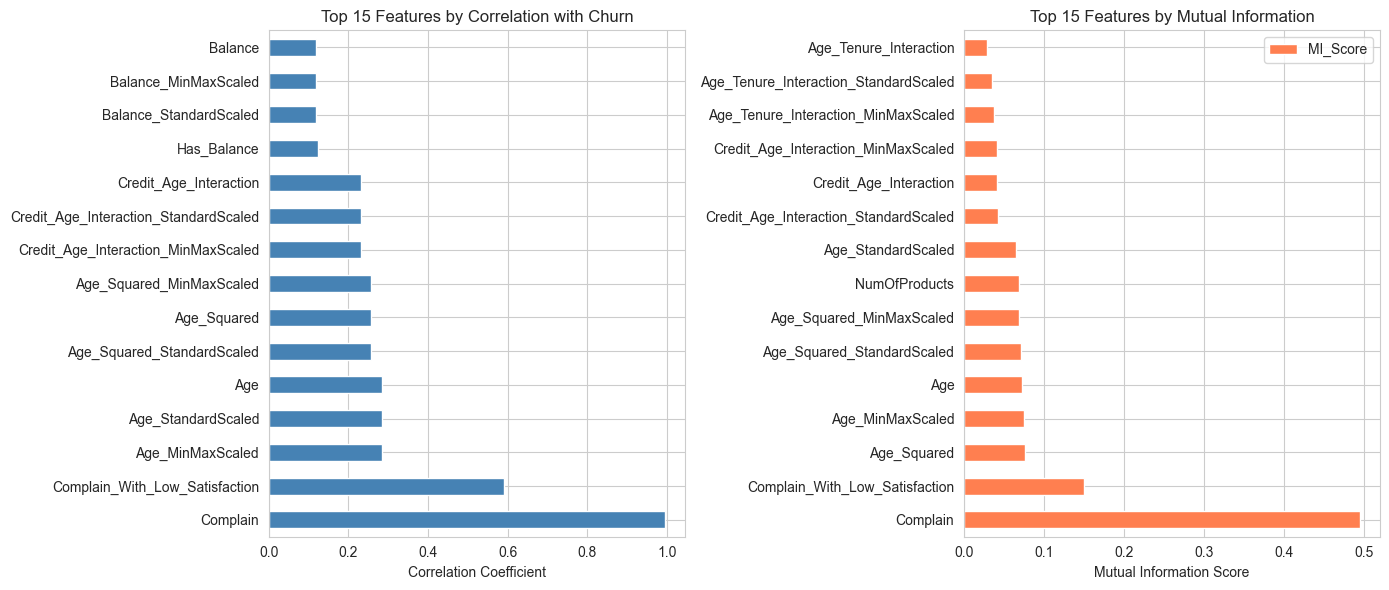


Top 15 Selected Features (Mutual Information):
['Age', 'NumOfProducts', 'Complain', 'Age_Tenure_Interaction', 'Credit_Age_Interaction', 'Age_Squared', 'Complain_With_Low_Satisfaction', 'Age_StandardScaled', 'Age_Tenure_Interaction_StandardScaled', 'Credit_Age_Interaction_StandardScaled', 'Age_Squared_StandardScaled', 'Age_MinMaxScaled', 'Age_Tenure_Interaction_MinMaxScaled', 'Credit_Age_Interaction_MinMaxScaled', 'Age_Squared_MinMaxScaled']


In [61]:
# Prepare data for feature selection
X = df_fe.select_dtypes(include=[np.number]).drop(['RowNumber', 'CustomerId', 'Exited'], axis=1, errors='ignore')
y = df_fe['Exited']

# Calculate correlation with target variable
correlations = X.corrwith(y).sort_values(ascending=False)
print("Top 15 Features by Correlation with Churn:")
print(correlations.head(15))
print("\nBottom 5 Features (negative correlation):")
print(correlations.tail(5))

# Mutual Information Feature Selection
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores_df = pd.DataFrame(mi_scores, columns=['MI_Score'], index=X.columns).sort_values('MI_Score', ascending=False)

print("\n\nTop 15 Features by Mutual Information:")
print(mi_scores_df.head(15))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Correlation plot
correlations.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Features by Correlation with Churn')
axes[0].set_xlabel('Correlation Coefficient')

# Mutual Information plot
mi_scores_df.head(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Features by Mutual Information')
axes[1].set_xlabel('Mutual Information Score')

plt.tight_layout()
plt.show()

# Select top k features using SelectKBest
k = 15
selector = SelectKBest(score_func=mutual_info_classif, k=k)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()].tolist()

print(f"\nTop {k} Selected Features (Mutual Information):")
print(selected_features)

## 9. Feature Importance Summary

In [62]:
print("="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

print(f"\nOriginal Dataset Shape: {df.shape}")
print(f"Engineered Dataset Shape: {df_fe.shape}")
print(f"New Features Created: {df_fe.shape[1] - df.shape[1]}")

print("\n" + "="*70)
print("FEATURE CATEGORIES:")
print("="*70)

print("\n1. ENCODED FEATURES:")
encoded_features = ['Gender_Encoded', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'CardType_Encoded']
print(encoded_features)

print("\n2. SCALED FEATURES (Sample):")
scaled_features = ['CreditScore_StandardScaled', 'Age_StandardScaled', 'EstimatedSalary_MinMaxScaled']
print(scaled_features[:3])

print("\n3. INTERACTION FEATURES:")
interaction_features = ['Age_Tenure_Interaction', 'Salary_Balance_Ratio', 'Credit_Age_Interaction']
print(interaction_features)

print("\n4. POLYNOMIAL FEATURES:")
polynomial_features = ['Age_Squared', 'CreditScore_Squared', 'Tenure_Squared']
print(polynomial_features)

print("\n5. BINNED/CATEGORICAL FEATURES:")
binned_features = ['Age_Group', 'CreditScore_Category', 'Tenure_Group']
print(binned_features)

print("\n6. DERIVED FEATURES:")
derived_features = ['Has_Balance', 'Active_Months', 'Complain_With_Low_Satisfaction']
print(derived_features)

print("\n" + "="*70)
print(f"Total Features for Modeling: {len(selected_features)}")
print("="*70)

# Save engineered dataset
df_fe.to_csv('Customer_Churn_Engineered_Features.csv', index=False)
print("\nEngineered dataset saved as 'Customer_Churn_Engineered_Features.csv'")

FEATURE ENGINEERING SUMMARY

Original Dataset Shape: (10000, 18)
Engineered Dataset Shape: (10000, 61)
New Features Created: 43

FEATURE CATEGORIES:

1. ENCODED FEATURES:
['Gender_Encoded', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'CardType_Encoded']

2. SCALED FEATURES (Sample):
['CreditScore_StandardScaled', 'Age_StandardScaled', 'EstimatedSalary_MinMaxScaled']

3. INTERACTION FEATURES:
['Age_Tenure_Interaction', 'Salary_Balance_Ratio', 'Credit_Age_Interaction']

4. POLYNOMIAL FEATURES:
['Age_Squared', 'CreditScore_Squared', 'Tenure_Squared']

5. BINNED/CATEGORICAL FEATURES:
['Age_Group', 'CreditScore_Category', 'Tenure_Group']

6. DERIVED FEATURES:
['Has_Balance', 'Active_Months', 'Complain_With_Low_Satisfaction']

Total Features for Modeling: 15

Engineered dataset saved as 'Customer_Churn_Engineered_Features.csv'

Engineered dataset saved as 'Customer_Churn_Engineered_Features.csv'


In [63]:
df_fe[selected_features].corr()

,Age,NumOfProducts,Complain,Age_Tenure_Interaction,Credit_Age_Interaction,Age_Squared,Complain_With_Low_Satisfaction,Age_StandardScaled,Age_Tenure_Interaction_StandardScaled,Credit_Age_Interaction_StandardScaled,Age_Squared_StandardScaled,Age_MinMaxScaled,Age_Tenure_Interaction_MinMaxScaled,Credit_Age_Interaction_MinMaxScaled,Age_Squared_MinMaxScaled
Age,1.000000,-0.030680,0.283530,0.402413,0.868155,0.983735,0.165476,1.000000,0.402413,0.868155,0.983735,1.000000,0.402413,0.868155,0.983735
NumOfProducts,-0.030680,1.000000,-0.046357,-0.001762,-0.021196,-0.029450,-0.033380,-0.030680,-0.001762,-0.021196,-0.029450,-0.030680,-0.001762,-0.021196,-0.029450
Complain,0.283530,-0.046357,1.000000,0.102132,0.230564,0.256090,0.591604,0.283530,0.102132,0.230564,0.256090,0.283530,0.102132,0.230564,0.256090
Age_Tenure_Interaction,0.402413,-0.001762,0.102132,1.000000,0.349668,0.396782,0.065751,0.402413,1.000000,0.349668,0.396782,0.402413,1.000000,0.349668,0.396782
Credit_Age_Interaction,0.868155,-0.021196,0.230564,0.349668,1.000000,0.856515,0.125626,0.868155,0.349668,1.000000,0.856515,0.868155,0.349668,1.000000,0.856515
Age_Squared,0.983735,-0.029450,0.256090,0.396782,0.856515,1.000000,0.149723,0.983735,0.396782,0.856515,1.000000,0.983735,0.396782,0.856515,1.000000
Complain_With_Low_Satisfaction,0.165476,-0.033380,0.591604,0.065751,0.125626,0.149723,1.000000,0.165476,0.065751,0.125626,0.149723,0.165476,0.065751,0.125626,0.149723
Age_StandardScaled,1.000000,-0.030680,0.283530,0.402413,0.868155,0.983735,0.165476,1.000000,0.402413,0.868155,0.983735,1.000000,0.402413,0.868155,0.983735
Age_Tenure_Interaction_StandardScaled,0.402413,-0.001762,0.102132,1.000000,0.349668,0.396782,0.065751,0.402413,1.000000,0.349668,0.396782,0.402413,1.000000,0.349668,0.396782
Credit_Age_Interaction_StandardScaled,0.868155,-0.021196,0.230564,0.349668,1.000000,0.856515,0.125626,0.868155,0.349668,1.000000,0.856515,0.868155,0.349668,1.000000,0.856515


## 10. Handling Multicollinearity (VIF Analysis and Removal)

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create correlation matrix from selected features
corr_matrix = df_fe[selected_features].corr()

# Function to identify highly correlated feature pairs
def identify_high_correlation_pairs(corr_matrix, threshold=0.9):
    """Identify feature pairs with correlation above threshold"""
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'Feature1': corr_matrix.columns[i],
                    'Feature2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs)

# Find highly correlated pairs
high_corr_pairs_df = identify_high_correlation_pairs(corr_matrix, threshold=0.9)
print("Features with High Correlation (>0.9):")
if len(high_corr_pairs_df) > 0:
    print(high_corr_pairs_df.to_string())
else:
    print("No feature pairs with correlation > 0.9 found")

# Calculate VIF (Variance Inflation Factor) for each feature
print("\n" + "="*70)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("="*70)

X_vif = df_fe[selected_features].copy()
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF Scores (VIF > 10 indicates high multicollinearity):")
print(vif_data.to_string(index=False))

# Identify features with high VIF (> 10)
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\nFeatures with VIF > 10 (High Multicollinearity): {high_vif_features}")

Features with High Correlation (>0.9):
                                 Feature1                               Feature2  Correlation
0                                     Age                            Age_Squared     0.983735
1                                     Age                     Age_StandardScaled     1.000000
2                                     Age             Age_Squared_StandardScaled     0.983735
3                                     Age                       Age_MinMaxScaled     1.000000
4                                     Age               Age_Squared_MinMaxScaled     0.983735
5                  Age_Tenure_Interaction  Age_Tenure_Interaction_StandardScaled     1.000000
6                  Age_Tenure_Interaction    Age_Tenure_Interaction_MinMaxScaled     1.000000
7                  Credit_Age_Interaction  Credit_Age_Interaction_StandardScaled     1.000000
8                  Credit_Age_Interaction    Credit_Age_Interaction_MinMaxScaled     1.000000
9                    


REMOVING COLLINEAR FEATURES

Starting with 15 features
Removing 'Age' (VIF = inf)
Removing 'Age' (VIF = inf)
Removing 'Age_Tenure_Interaction' (VIF = inf)
Removing 'Credit_Age_Interaction' (VIF = inf)
Removing 'Age_Tenure_Interaction' (VIF = inf)
Removing 'Credit_Age_Interaction' (VIF = inf)
Removing 'Age_Squared' (VIF = inf)
Removing 'Age_StandardScaled' (VIF = inf)
Removing 'Age_Tenure_Interaction_StandardScaled' (VIF = inf)
Removing 'Age_Squared' (VIF = inf)
Removing 'Age_StandardScaled' (VIF = inf)
Removing 'Age_Tenure_Interaction_StandardScaled' (VIF = inf)
Removing 'Credit_Age_Interaction_StandardScaled' (VIF = inf)
Removing 'Age_Squared_MinMaxScaled' (VIF = 206.47)
Removing 'Age_MinMaxScaled' (VIF = 34.22)
Removing 'Credit_Age_Interaction_MinMaxScaled' (VIF = 8.23)

Final Feature Set: 5 features
Removed Features: ['Age', 'Age_Tenure_Interaction', 'Credit_Age_Interaction', 'Age_Squared', 'Age_StandardScaled', 'Age_Tenure_Interaction_StandardScaled', 'Credit_Age_Interaction_Stand

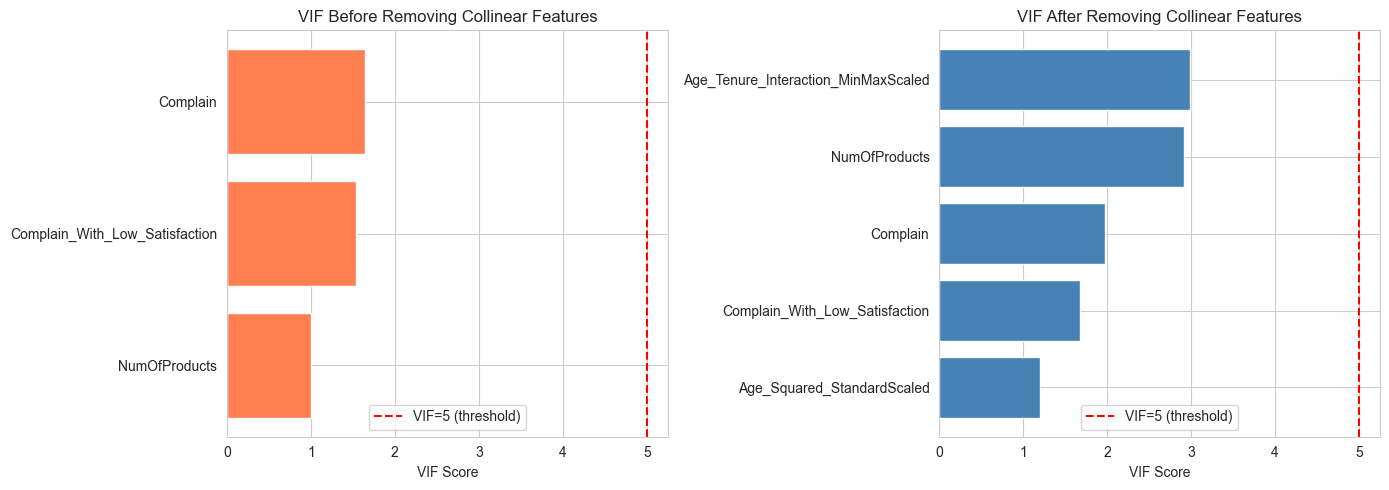

In [65]:
print("\n" + "="*70)
print("REMOVING COLLINEAR FEATURES")
print("="*70)

# Strategy: Iteratively remove features with highest VIF > 10
features_to_use = selected_features.copy()
removed_features = []

print(f"\nStarting with {len(features_to_use)} features")

# Iteratively remove high VIF features
while True:
    X_temp = df_fe[features_to_use].copy()
    vif_scores = pd.DataFrame()
    vif_scores["Feature"] = X_temp.columns
    vif_scores["VIF"] = [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]
    
    max_vif = vif_scores['VIF'].max()
    
    if max_vif <= 5:  # VIF threshold of 5 (moderate multicollinearity)
        break
    
    # Remove feature with highest VIF
    feature_to_remove = vif_scores.loc[vif_scores['VIF'].idxmax(), 'Feature']
    print(f"Removing '{feature_to_remove}' (VIF = {max_vif:.2f})")
    
    features_to_use.remove(feature_to_remove)
    removed_features.append(feature_to_remove)

print(f"\nFinal Feature Set: {len(features_to_use)} features")
print(f"Removed Features: {removed_features}")
print(f"\nFinal Selected Features:")
for i, feat in enumerate(features_to_use, 1):
    print(f"{i}. {feat}")

# Calculate final VIF scores
print("\n" + "="*70)
print("FINAL VIF SCORES (After Removing Collinear Features)")
print("="*70)

X_final = df_fe[features_to_use].copy()
final_vif = pd.DataFrame()
final_vif["Feature"] = X_final.columns
final_vif["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
final_vif = final_vif.sort_values('VIF', ascending=False)

print(final_vif.to_string(index=False))

# Visualize VIF comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original VIF
vif_data_sorted = vif_data.sort_values('VIF', ascending=True).tail(15)
axes[0].barh(vif_data_sorted['Feature'], vif_data_sorted['VIF'], color='coral')
axes[0].axvline(x=5, color='red', linestyle='--', label='VIF=5 (threshold)')
axes[0].set_title('VIF Before Removing Collinear Features')
axes[0].set_xlabel('VIF Score')
axes[0].legend()

# Final VIF
final_vif_sorted = final_vif.sort_values('VIF', ascending=True)
axes[1].barh(final_vif_sorted['Feature'], final_vif_sorted['VIF'], color='steelblue')
axes[1].axvline(x=5, color='red', linestyle='--', label='VIF=5 (threshold)')
axes[1].set_title('VIF After Removing Collinear Features')
axes[1].set_xlabel('VIF Score')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Final Clean Dataset Export

In [66]:
# Create final dataset with cleaned features
df_final = df_fe[features_to_use + ['Exited']].copy()

print("="*70)
print("FINAL DATASET SUMMARY")
print("="*70)

print(f"\nOriginal Features: {len(selected_features)}")
print(f"Final Features (after removing collinearity): {len(features_to_use)}")
print(f"Features Removed: {len(removed_features)}")
print(f"Removed Features: {removed_features}")

print(f"\nFinal Dataset Shape: {df_final.shape}")
print(f"\nDataset Info:")
print(f"Target Variable (Exited) Distribution:")
print(df_final['Exited'].value_counts())

# Save final dataset
df_final.to_csv('Customer_Churn_Final_Features.csv', index=False)
print("\n✓ Final dataset saved as 'Customer_Churn_Final_Features.csv'")

# Create a summary report
summary_report = f"""
FEATURE ENGINEERING & MULTICOLLINEARITY HANDLING REPORT
{'='*70}

1. ORIGINAL DATASET
   - Shape: {df.shape}
   - Target Variable: Exited (Churn)

2. FEATURE ENGINEERING
   - Total Features Created: {df_fe.shape[1] - df.shape[1]}
   - Engineered Dataset Shape: {df_fe.shape}

3. FEATURE SELECTION (Mutual Information)
   - Top Features Selected: {len(selected_features)}

4. MULTICOLLINEARITY ANALYSIS
   - Initial VIF Assessment: {len(selected_features)} features
   - Features with VIF > 5: {len(removed_features)}
   - Final Features: {len(features_to_use)}
   
5. REMOVED FEATURES (High VIF):
   {chr(10).join([f"   - {feat}" for feat in removed_features])}

6. FINAL FEATURES FOR MODELING:
   {chr(10).join([f"   {i}. {feat}" for i, feat in enumerate(features_to_use, 1)])}

7. READY FOR MODELING
   - Dataset: Customer_Churn_Final_Features.csv
   - Features: {len(features_to_use)}
   - Samples: {len(df_final)}
   - All features have VIF < 5 (low multicollinearity)
"""

print(summary_report)

# Save summary report
with open('Feature_Engineering_Report.txt', 'w') as f:
    f.write(summary_report)
print("\n✓ Summary report saved as 'Feature_Engineering_Report.txt'")

FINAL DATASET SUMMARY

Original Features: 15
Final Features (after removing collinearity): 5
Features Removed: 10
Removed Features: ['Age', 'Age_Tenure_Interaction', 'Credit_Age_Interaction', 'Age_Squared', 'Age_StandardScaled', 'Age_Tenure_Interaction_StandardScaled', 'Credit_Age_Interaction_StandardScaled', 'Age_Squared_MinMaxScaled', 'Age_MinMaxScaled', 'Credit_Age_Interaction_MinMaxScaled']

Final Dataset Shape: (10000, 6)

Dataset Info:
Target Variable (Exited) Distribution:
Exited
0    7962
1    2038
Name: count, dtype: int64

✓ Final dataset saved as 'Customer_Churn_Final_Features.csv'

FEATURE ENGINEERING & MULTICOLLINEARITY HANDLING REPORT

1. ORIGINAL DATASET
   - Shape: (10000, 18)
   - Target Variable: Exited (Churn)

2. FEATURE ENGINEERING
   - Total Features Created: 43
   - Engineered Dataset Shape: (10000, 61)

3. FEATURE SELECTION (Mutual Information)
   - Top Features Selected: 15

4. MULTICOLLINEARITY ANALYSIS
   - Initial VIF Assessment: 15 features
   - Features wi

In [67]:
df_final

,NumOfProducts,Complain,Complain_With_Low_Satisfaction,Age_Squared_StandardScaled,Age_Tenure_Interaction_MinMaxScaled,Exited
0,1,1,1,0.147532,0.095455,1
1,1,1,0,0.059507,0.046591,0
2,3,1,0,0.147532,0.381818,1
3,2,0,0,-0.110179,0.044318,0
4,1,0,0,0.237678,0.097727,0
...,...,...,...,...,...,...
9995,2,0,0,-0.110179,0.221591,0
9996,1,0,0,-0.424099,0.397727,0
9997,1,1,0,-0.348801,0.286364,1
9998,2,1,1,0.147532,0.143182,1
